# Quickstart

This walks the whole flow on a small dataset: load a table, attach the spec
limits, run an analysis, read the result. Every cell runs, so open it in Colab
and change the numbers to your own.

<div class="nb-buttons"><a class="nb-btn" target="_blank" href="https://colab.research.google.com/github/cjbrant/mfgQC/blob/main/docs/guide/quickstart.ipynb">Run in Colab</a><a class="nb-btn" target="_blank" href="https://github.com/cjbrant/mfgQC/blob/main/docs/guide/quickstart.ipynb">View on GitHub</a><a class="nb-btn" target="_blank" href="https://raw.githubusercontent.com/cjbrant/mfgQC/main/docs/guide/quickstart.ipynb" download>Download notebook</a></div>

Install it first (skip this if mfgQC is already in your environment):

In [ ]:
!pip install mfgqc

## 1. Load a table and attach the spec

mfgQC analyses take a `QCData` object. You build one by loading a tidy
DataFrame, naming the measurement column, and attaching the engineering
tolerances. Here is a made-up run of 100 widths in 20 subgroups of 5.

In [2]:
import numpy as np, pandas as pd, mfgqc

rng = np.random.default_rng(7)
df = pd.DataFrame({
    "width": np.round(rng.normal(1.50, 0.11, 100), 3),
    "lot":   np.repeat(np.arange(1, 21), 5),
})

qc = (mfgqc.load(df, measure="width", subgroup="lot", subgroup_size=5)
           .spec(lower=1.0, upper=2.0, target=1.5))
qc

QCData(measure='width', n=100, roles={subgroup}, spec(lower=1.0, upper=2.0, target=1.5), history=2 steps)

`measure` is the value column, `subgroup` groups the rows into rational
subgroups, and `.spec(...)` attaches the limits. Everything is immutable, so
each call hands back a new object.

## 2. Capability

Run it and print the report.

In [3]:
print(qc.capability())

Process Capability (method=normal)
n = 100   mean = 1.4809
sigma (within)  = 0.1013
sigma (overall) = 0.096767
Cp/Cpk sigma    = within (R-bar/d2)

Cp  = 1.645  95% CI (1.42, 1.87)
Cpk = 1.583  95% CI (1.35, 1.81)   (Cpu=1.708, Cpl=1.583)
Pp  = 1.722    Ppk = 1.657   (Ppu=1.788, Ppl=1.657)
Cpm = 1.69

Assumption checks:
  [PASS] normality (Anderson-Darling): AD=0.305, p=0.563; est. Cpk impact 4.9%; n=100
  [FAIL] subgroup_sufficiency (subgroup count >= 25): subgroup count 20; n=20

Recommendations:
  - Only 20 subgroups; >=25 recommended for a stable within-sigma estimate.


Three things to notice. Both sigma families are reported: within-subgroup
(Cp, Cpk) and overall (Pp, Ppk), with the estimator named. Confidence
intervals are shown because small-sample point estimates run optimistic. And
the assumptions are checked and printed. Here normality passes but the
subgroup count is flagged as low. mfgQC tells you and recommends a fix. It does
not quietly change the math.

Every result also draws its own chart.

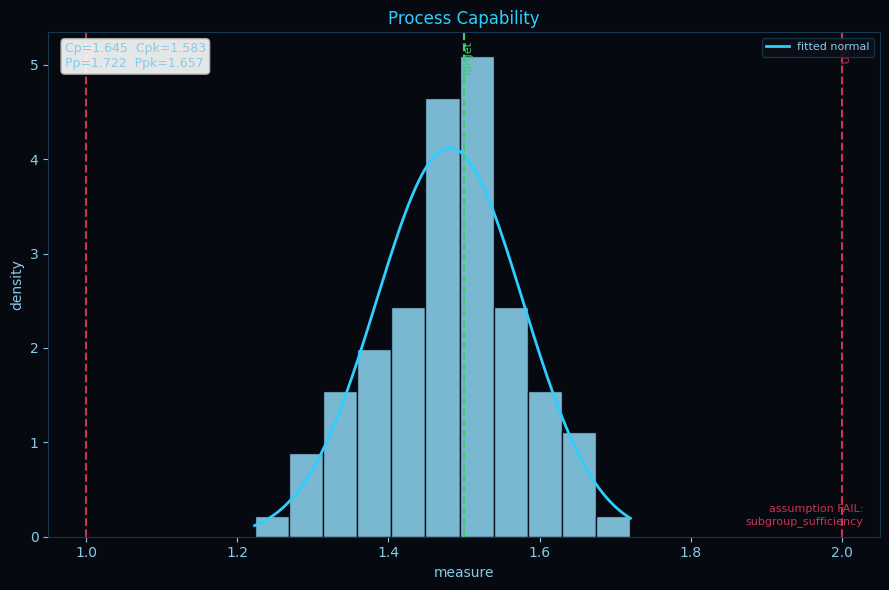

In [4]:
qc.capability().view()

## 3. Control chart

With no `kind`, mfgQC picks the chart from the subgroup size. Five per
subgroup gives an X-bar and R chart.

In [5]:
print(qc.control_chart())

Control Chart: xbar_r (inferred); rules=nelson
Xbar: CL=1.4809  UCL=1.6169  LCL=1.345
R: CL=0.2356  UCL=0.49806  LCL=0

Out-of-control signals: none (process in control)

Assumption checks:
  [PASS] independence (lag-1 autocorrelation): r=0.193, p=0.388; n=20 [low power]


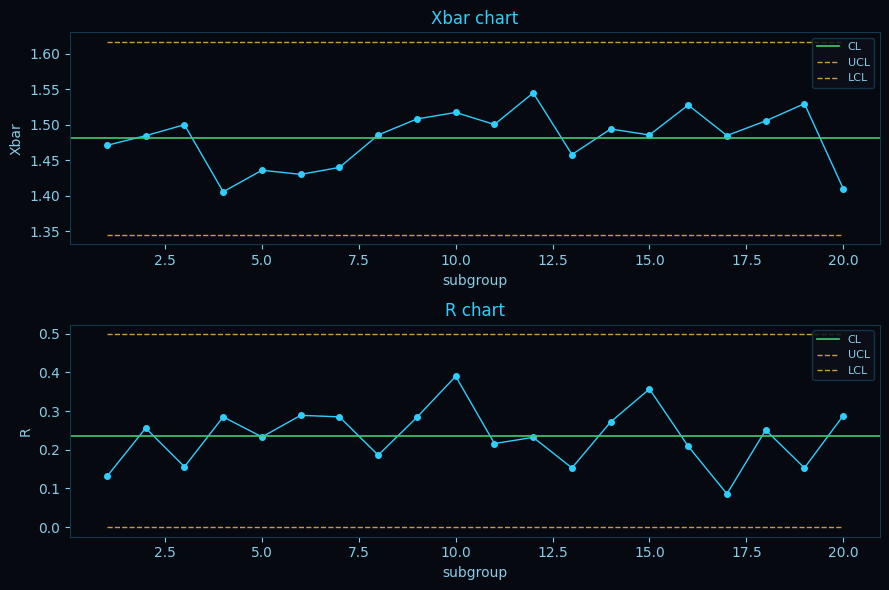

In [6]:
qc.control_chart().view()

## 4. One shape for everything

Every analysis returns the same surface, so once you know one you know them all.

In [7]:
cap = qc.capability()

cap.summary()        # a flat dict of the headline numbers

{'method': 'normal',
 'n': 100,
 'mean': 1.4809300000000005,
 'sigma_within': 0.10128976784178846,
 'sigma_overall': 0.09676685038448513,
 'Cp': 1.6454442558007925,
 'Cp_CI_low': 1.4164408239749233,
 'Cp_CI_high': 1.8740676845678936,
 'Cpk': 1.582687011884552,
 'Cpk_CI_low': 1.3527596612613806,
 'Cpk_CI_high': 1.8126143625077233,
 'Pp': 1.7223529132595263,
 'Ppk': 1.6566623731478098,
 'Cpm': np.float64(1.689850920191613),
 'confidence': 95,
 'normality_passed': True}

- `cap.report()` is the text above.
- `cap.summary()` is the flat dict you just saw.
- `cap.to_dict()` is the full JSON payload (numbers, assumption checks, provenance). Read this from code, never the text.
- `cap.view()` is the chart.

## Next

- [Reading the assumption report](/guide/assumption-report/) explains the guardrails.
- [Gage R&R study](/guide/gage-rr/) walks a measurement-system study end to end.
- The [Reference](/reference/) gives the formula, assumptions, and source standard behind every method.